In [51]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
!pip install contractions
import contractions
from wordcloud import WordCloud


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Datasets/Hotel_Reviews.csv')

print(df.shape)
df.head()

(20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [8]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


,Rating
count,20491.000000
mean,3.952223
std,1.233030
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


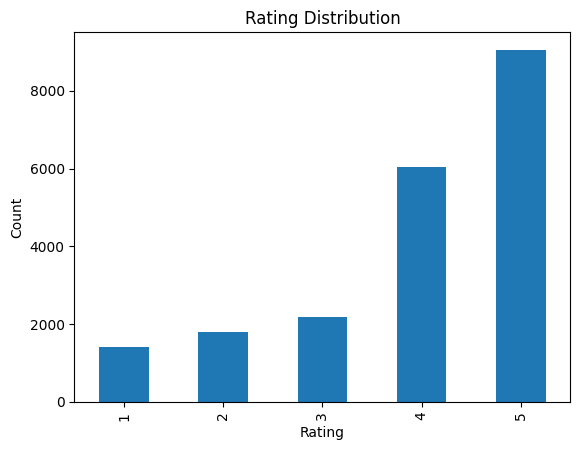

In [9]:
df['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [10]:
df['sentiment'] = df['Rating'].apply(
    lambda x: "positive" if x >= 4 else
              "negative" if x <= 2 else
              "neutral"
)

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print(le.classes_)

['negative' 'neutral' 'positive']


In [17]:
import re
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

In [20]:
df['clean_text'] = df['Review'].apply(clean_text)

df[['Review', 'clean_text']].head()

,Review,clean_text
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


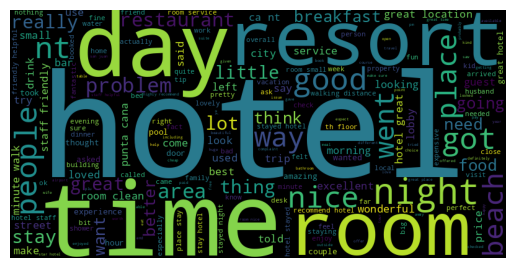

In [21]:
text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

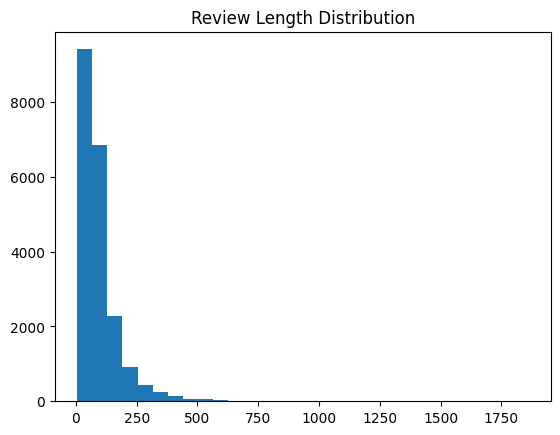

In [22]:
df['length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.hist(df['length'], bins=30)
plt.title("Review Length Distribution")
plt.show()

In [23]:
VOCAB_SIZE = 6000

tokenizer = Tokenizer(num_words=VOCAB_SIZE)
tokenizer.fit_on_texts(df['clean_text'])

seq = tokenizer.texts_to_sequences(df['clean_text'])

In [24]:
max_len = int(np.percentile([len(s) for s in seq], 95))

X = pad_sequences(seq, maxlen=max_len)
y = df['label'].values

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Model 1 Simple RNN

In [27]:
model1 = Sequential()

model1.add(Embedding(input_dim=VOCAB_SIZE,
                     output_dim=64,
                     input_length=max_len))

model1.add(SimpleRNN(64))

model1.add(Dense(3, activation='softmax'))

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [29]:
es = EarlyStopping(patience=3, restore_best_weights=True)

history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[es]
)

Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - accuracy: 0.7271 - loss: 0.7246 - val_accuracy: 0.7902 - val_loss: 0.5705
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.8278 - loss: 0.4566 - val_accuracy: 0.7368 - val_loss: 0.7064
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.8441 - loss: 0.4156 - val_accuracy: 0.8322 - val_loss: 0.4953
Epoch 4/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 23s 88ms/step - accuracy: 0.9329 - loss: 0.1975 - val_accuracy: 0.8090 - val_loss: 0.5707
Epoch 5/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - accuracy: 0.9839 - loss: 0.0707 - val_accuracy: 0.7873 - val_loss: 0.6905
Epoch 6/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9980 - loss: 0.0200 - val_accuracy: 0.8007 - val_loss: 0.7626


In [30]:
loss1, acc1 = model1.evaluate(X_test, y_test)

print("MODEL 1 RESULTS")
print("Test Loss:", loss1)
print("Test Accuracy:", acc1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8322 - loss: 0.4953
MODEL 1 RESULTS
Test Loss: 0.49528348445892334
Test Accuracy: 0.8321541547775269


In [31]:
y_pred1 = np.argmax(model1.predict(X_test), axis=1)
print("MODEL 1 - SIMPLE RNN REPORT")
print(classification_report(y_test, y_pred1))

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
MODEL 1 - SIMPLE RNN REPORT
              precision    recall  f1-score   support

           0       0.70      0.79      0.74       643
           1       0.26      0.04      0.07       437
           2       0.87      0.96      0.91      3019

    accuracy                           0.83      4099
   macro avg       0.61      0.59      0.57      4099
weighted avg       0.78      0.83      0.80      4099



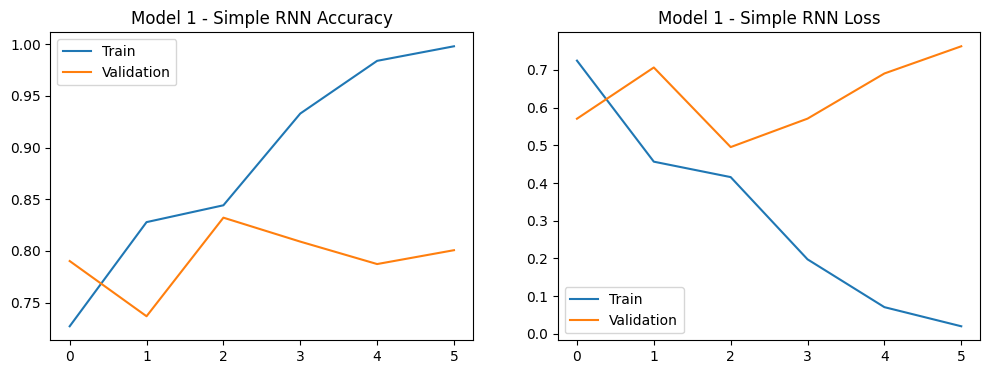

In [32]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(title + " Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(title + " Loss")
    plt.legend()

    plt.show()

plot_history(history1, "Model 1 - Simple RNN")

Model 2 LSTM

In [33]:
model2 = Sequential()
model2.add(Embedding(VOCAB_SIZE, 64, input_length=max_len))
model2.add(LSTM(64))
model2.add(Dense(3, activation='softmax'))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [35]:
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[es]
)

Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 53s 193ms/step - accuracy: 0.7851 - loss: 0.5893 - val_accuracy: 0.8136 - val_loss: 0.4896
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 51s 199ms/step - accuracy: 0.8442 - loss: 0.4058 - val_accuracy: 0.8453 - val_loss: 0.4197
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 51s 197ms/step - accuracy: 0.8747 - loss: 0.3303 - val_accuracy: 0.8480 - val_loss: 0.4175
Epoch 4/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 49s 189ms/step - accuracy: 0.9004 - loss: 0.2704 - val_accuracy: 0.8278 - val_loss: 0.4341
Epoch 5/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 189ms/step - accuracy: 0.9217 - loss: 0.2185 - val_accuracy: 0.8236 - val_loss: 0.4781
Epoch 6/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 49s 189ms/step - accuracy: 0.9364 - loss: 0.1790 - val_accuracy: 0.8175 - val_loss: 0.5021


In [36]:
loss2, acc2 = model2.evaluate(X_test, y_test)

print("MODEL 2 RESULTS")
print("Test Loss:", loss2)
print("Test Accuracy:", acc2)

129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.8480 - loss: 0.4175
MODEL 2 RESULTS
Test Loss: 0.4174751341342926
Test Accuracy: 0.8480117321014404


In [37]:
y_pred2 = np.argmax(model2.predict(X_test), axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step


In [38]:
print("MODEL 2 - LSTM REPORT")
print(classification_report(y_test, y_pred2))

MODEL 2 - LSTM REPORT
              precision    recall  f1-score   support

           0       0.76      0.77      0.77       643
           1       0.41      0.17      0.24       437
           2       0.89      0.96      0.92      3019

    accuracy                           0.85      4099
   macro avg       0.69      0.63      0.64      4099
weighted avg       0.82      0.85      0.83      4099



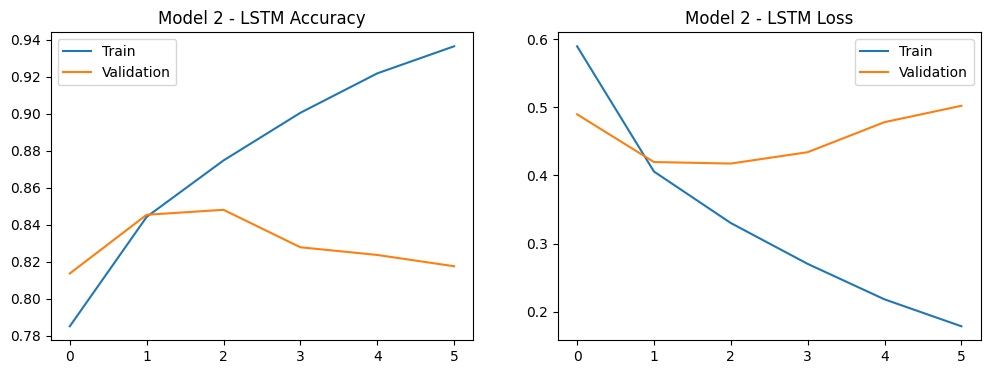

In [39]:
plot_history(history2, "Model 2 - LSTM")

Model 3 LSTM + WORD2VEC

In [41]:
!pip install gensim
import gensim.downloader as api
wv = api.load("glove-twitter-25")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.4 MB/s eta 0:00:00
[==================================================] 100.0% 104.8/104.8MB downloaded


In [42]:
embedding_dim = 25
word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))

for word, i in word_index.items():
    if i < VOCAB_SIZE and word in wv:
        embedding_matrix[i] = wv[word]

In [43]:
model3 = Sequential()

model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
))

model3.add(LSTM(64))

model3.add(Dense(3, activation='softmax'))

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │       150,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,000 (585.94 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 150,000 (585.94 KB)

In [52]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(2.1252430960715674), 1: np.float64(3.1276473955352033), 2: np.float64(0.4525426536359119)}


In [53]:
model3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [54]:
history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[es]
)

Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 45s 152ms/step - accuracy: 0.7801 - loss: 0.5843 - val_accuracy: 0.7819 - val_loss: 0.5524
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 41s 158ms/step - accuracy: 0.8065 - loss: 0.5177 - val_accuracy: 0.8182 - val_loss: 0.5129
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 38s 147ms/step - accuracy: 0.8171 - loss: 0.4839 - val_accuracy: 0.8187 - val_loss: 0.4709


In [55]:
loss3, acc3 = model3.evaluate(X_test, y_test)

print("MODEL 3 RESULTS")
print("Test Loss:", loss3)
print("Test Accuracy:", acc3)

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7819 - loss: 0.5524
MODEL 3 RESULTS
Test Loss: 0.5524277091026306
Test Accuracy: 0.781898021697998


In [56]:
y_pred3 = np.argmax(model3.predict(X_test), axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step


In [58]:
print(classification_report(
    y_test,
    y_pred3,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.50      0.71      0.58       643
           1       0.00      0.00      0.00       437
           2       0.87      0.91      0.89      3019

    accuracy                           0.78      4099
   macro avg       0.45      0.54      0.49      4099
weighted avg       0.72      0.78      0.75      4099



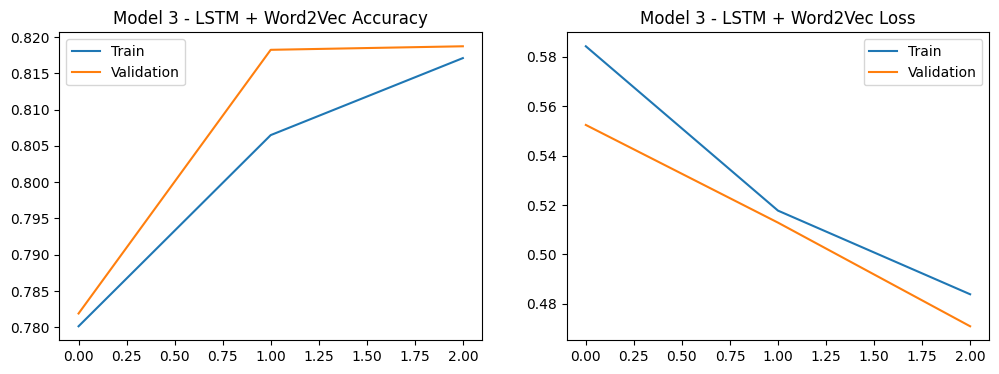

In [59]:
plot_history(history3, "Model 3 - LSTM + Word2Vec")

In [60]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "LSTM+Word2Vec"],
    "Accuracy": [acc1, acc2, acc3],
    "Loss": [loss1, loss2, loss3]
})

print(results)

           Model  Accuracy      Loss
0            RNN  0.832154  0.495283
1           LSTM  0.848012  0.417475
2  LSTM+Word2Vec  0.781898  0.552428


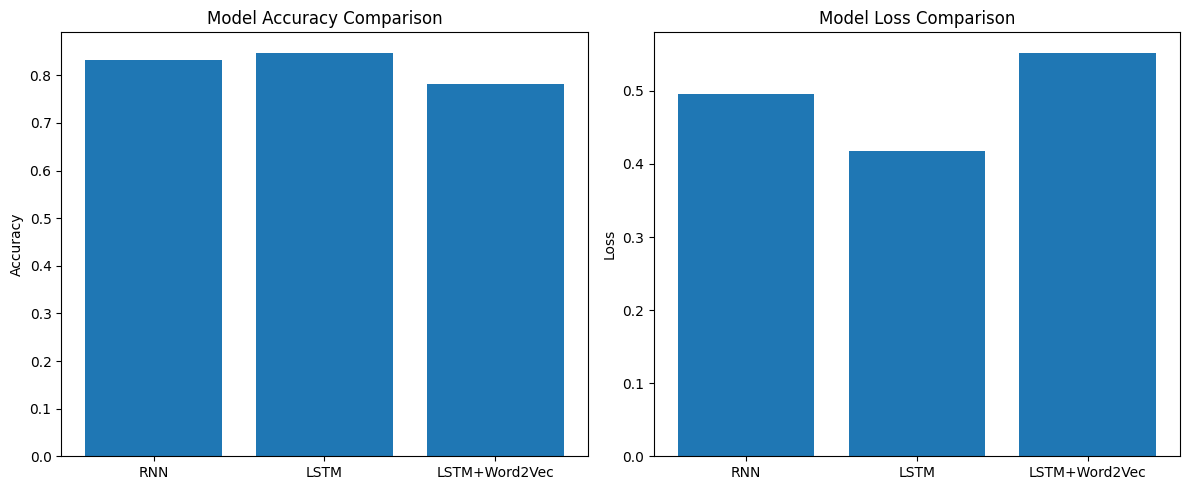

In [61]:
models = ['RNN', 'LSTM', 'LSTM+Word2Vec']
accuracy = [acc1, acc2, acc3]
loss = [loss1, loss2, loss3]

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

# Loss Plot
plt.subplot(1,2,2)
plt.bar(models, loss)
plt.title("Model Loss Comparison")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

  Error Analysis

In [62]:
# Convert predictions back to labels
pred_labels = le.inverse_transform(y_pred2)
true_labels = le.inverse_transform(y_test)

# Get original test reviews
X_test_indices = X_test.shape[0]

misclassified = []

for i in range(len(y_test)):
    if y_test[i] != y_pred2[i]:

        misclassified.append({
            "Original Review": df.iloc[i]['Review'],
            "Cleaned Review": df.iloc[i]['clean_text'],
            "Actual": true_labels[i],
            "Predicted": pred_labels[i]
        })

# Show first 3 mistakes
for i, item in enumerate(misclassified[:3], 1):

    print(f"\n--- Misclassified Example {i} ---")
    print("Original Review:")
    print(item['Original Review'])

    print("\nCleaned Review:")
    print(item['Cleaned Review'])

    print("\nActual Sentiment:", item['Actual'])
    print("Predicted Sentiment:", item['Predicted'])


--- Misclassified Example 1 ---
Original Review:
ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like tv couch ect desk clerk told oh mixed suites description kimpton website sorry free breakfast, got kidding, embassy suits sitting room bathroom bedroom unlike kimpton calls suite, 5 day stay offer correct false advertising, send kimpton preferred guest website email asking failure provide suite advertised website reservation description furnished hard copy reservation printout website desk manager duty did not reply solution, send email trip guest survey did not follow email mail, guess tell concerned guest.the staff ranged indifferent not helpful, asked desk good breakfast spots neighborhood hood told no hotels, gee best breakfast spots seattle 1/2 block away convenient hotel does not know exis

GUI

In [63]:
!pip install gradio -q

In [64]:
def predict_review(review):

    # Clean text
    cleaned = clean_text(review)

    # Convert to sequence
    seq = tokenizer.texts_to_sequences([cleaned])

    # Padding
    padded = pad_sequences(seq, maxlen=max_len)

    # Predict
    pred = model2.predict(padded)

    # Get class
    label = le.inverse_transform([np.argmax(pred)])[0]

    # Confidence
    confidence = np.max(pred) * 100

    return f"Predicted Sentiment: {label}\nConfidence: {confidence:.2f}%"

In [65]:
import gradio as gr

demo = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter hotel review here..."
    ),
    outputs="text",
    title="Hotel Review Sentiment Analysis",
    description="Predicts whether a hotel review is Positive, Neutral, or Negative using LSTM."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9b9c8bff57abc33602.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


This project implemented three deep learning models for hotel review sentiment classification: Simple RNN, LSTM, and LSTM with pretrained Word2Vec embeddings.

Among all models, the LSTM model achieved the best performance with an accuracy of approximately 84.8%, demonstrating its effectiveness in capturing long-term dependencies in textual data. The Simple RNN model also performed reasonably well but struggled with complex contextual relationships in long reviews.

The pretrained Word2Vec model showed lower performance due to vocabulary mismatch between Twitter-based embeddings and hotel review data, as well as dataset imbalance issues.

Error analysis revealed that neutral reviews were the most difficult to classify because they often contained mixed positive and negative sentiments. Despite these challenges, the models successfully learned meaningful sentiment patterns from hotel review text.